# Phase 3 Strojové učenie

## Importy

In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


TRAIN_PATH = "processed/train_std.csv"
TEST_PATH = "processed/test_std.csv"
TARGET_COL = "oximetry"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude,oximetry
0,-0.212181,-0.283977,-0.961673,-1.096729,0.671882,-1.726660,0.907547,0.747585,1.711609,-0.184376,...,-0.399321,1.737000,0.742342,1.120023,-0.563050,1.303860,0.014961,0.492058,-1.172763,1.0
1,-1.221620,1.409044,-0.531067,-0.686905,0.556444,0.497449,0.813390,0.300029,1.216281,0.196289,...,1.149775,0.628474,-0.397799,-0.089499,1.889279,-1.357021,-0.884478,0.603620,-1.284282,1.0
2,-0.018230,1.834341,1.024363,-0.509595,-0.948750,0.015322,0.789674,-0.008516,-1.216643,0.553323,...,2.145306,-0.552293,-0.141816,1.458561,-0.127506,-1.005631,0.562910,0.162366,-0.237312,0.0
3,-0.784025,1.357692,0.485828,-0.789177,-0.508072,-0.430137,0.257498,-0.242366,-1.148415,-0.365390,...,1.035635,-1.035744,0.142962,0.273825,-0.738886,-0.419158,-0.274548,0.185725,-1.765463,0.0
4,0.567762,0.743549,-2.209355,1.530722,1.175073,-0.129554,-0.927751,0.308699,1.133135,-1.391575,...,0.219173,0.477632,-1.178020,0.856171,-0.194711,-1.622471,-1.084355,0.839309,0.000765,1.0


## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach



V tejto časti sme implementovali vlastný rozhodovací strom podľa algoritmu ID3.  
Cieľom bolo pochopiť základné mechanizmy rozhodovacích stromov a otestovať, ako dobre dokáže jednoduchý strom klasifikovať premennú `oximetry` na našom datasete.

### 3.1-A Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň)

In [2]:


feature_cols = [c for c in train_df.columns if c != TARGET_COL]

# Rozdelenie na vstupne premenne a cielovu premennu
X_train = train_df[feature_cols].values
y_train = train_df[TARGET_COL].values

X_test = test_df[feature_cols].values
y_test = test_df[TARGET_COL].values

X_train.shape, X_test.shape

((9734, 22), (2434, 22))

#### Funkcie na entropiu a information gain

In [3]:
def entropy(y: np.ndarray) -> float:
    #vypocet entropie
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -(p * np.log2(p + 1e-9)).sum()  # + mala hodkota kvoli logu(0)


def best_split_for_feature(X_column: np.ndarray, y: np.ndarray):
    # funkcia na best spit pre jednu feature
    # unikatne hodnoty v stlpci
    values = np.unique(X_column)
    if len(values) == 1:
        return None, 0.0

    #premenne na sledovanie najlepsieho splitu
    best_gain = 0.0
    best_threshold = None

    base_entropy = entropy(y)
    n = len(y)

    thresholds = (values[:-1] + values[1:]) / 2.0

    for t in thresholds:
        left_mask = X_column <= t
        right_mask = X_column > t

        y_left = y[left_mask]
        y_right = y[right_mask]

        if len(y_left) == 0 or len(y_right) == 0:
            continue

        ent_left = entropy(y_left)
        ent_right = entropy(y_right)

        weighted_ent = (len(y_left) / n) * ent_left + (len(y_right) / n) * ent_right
        gain = base_entropy - weighted_ent

        if gain > best_gain:
            best_gain = gain
            best_threshold = t

    return best_threshold, best_gain


#### Uzol stromu

In [4]:
class TreeNode:
    def __init__(self, 
                 feature_index=None, 
                 threshold=None, 
                 left=None, 
                 right=None, 
                 value=None,
                 depth=0):
        # index feature, podľa ktorého sa delí
        self.feature_index = feature_index
        # threshold pre num split
        self.threshold = threshold
        # left right child uzly
        self.left = left
        self.right = right
        # hodnota listu
        self.value = value
        # hĺbka uzla pre infoinfo/overfitting
        self.depth = depth

    def is_leaf(self):
        return self.value is not None


#### Implementacia ID3 klasifikátora

In [5]:
class ID3Classifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        
        #max_depth: maximálna hĺbka stromu (root má depth=0)
        #min_samples_split: minimálny počet vzoriek na ďalšie delenie
        
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))
        # Stopping conditions
        if num_labels == 1:
            leaf_value = y[0]
            return TreeNode(value=leaf_value, depth=depth)

        if depth >= self.max_depth or num_samples < self.min_samples_split:
            # list – väčšinová trieda
            values, counts = np.unique(y, return_counts=True)
            leaf_value = values[np.argmax(counts)]
            return TreeNode(value=leaf_value, depth=depth)

        # Hľadanie najlepšieho splitu
        best_gain = 0.0
        best_feature = None
        best_threshold = None

        for feature_idx in range(num_features):
            threshold, gain = best_split_for_feature(X[:, feature_idx], y)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

        
        if best_gain == 0 or best_feature is None:
            values, counts = np.unique(y, return_counts=True)
            leaf_value = values[np.argmax(counts)]
            return TreeNode(value=leaf_value, depth=depth)

        # rozdelenie dát podla best splitu
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return TreeNode(feature_index=best_feature,
                        threshold=best_threshold,
                        left=left_child,
                        right=right_child,
                        depth=depth)

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _predict_one(self, x, node: TreeNode):
        if node.is_leaf():
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


Najskôr sme naprogramovali vlastnú verziu ID3 s podporou pre číselné atribúty.  
Implementácia zahŕňa výpočet entropie, information gain, hľadanie najlepšieho splitu a rekurzívnu stavbu stromu.  
Strom má obmedzenú hĺbku, aby sme predišli prílišnému prevzdelaniu.

### 3.1-B Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall.

In [6]:
id3 = ID3Classifier(max_depth=5, min_samples_split=5)
id3.fit(X_train, y_train)

y_train_pred = id3.predict(X_train)
y_test_pred = id3.predict(X_test)

def print_metrics(name, y_true, y_pred):
    print("---",name,"---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print()

print_metrics("ID3 - TRAIN", y_train, y_train_pred)
print_metrics("ID3 - TEST", y_test, y_test_pred)

print("Detailnejší report (test):")
print(classification_report(y_test, y_test_pred, zero_division=0))

--- ID3 - TRAIN ---
Accuracy : 0.892233408670639
Precision: 0.9116883116883117
Recall   : 0.9071330117160579

--- ID3 - TEST ---
Accuracy : 0.8935907970419064
Precision: 0.9162011173184358
Recall   : 0.9042039972432805

Detailnejší report (test):
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       983
         1.0       0.92      0.90      0.91      1451

    accuracy                           0.89      2434
   macro avg       0.89      0.89      0.89      2434
weighted avg       0.89      0.89      0.89      2434



Model sme vyhodnotili na trénovacej aj testovacej sade.  
Metriky ukázali, že ID3 dosahuje stabilnú presnosť približne na úrovni 0.89 a vykazuje veľmi podobné výsledky na train aj test datasetoch.


### 3.1-C Test na overfiting

Aby sme overili, či sa model preučuje, testovali sme dve rôzne konfigurácie:  
-   hĺbkový strom (vyšší riskoverfittingu)
-   regulovaný strom (nižší risk overfittingu).  

In [7]:
# "Veľmi hlboký" strom – možno overfit
id3_overfit = ID3Classifier(max_depth=10, min_samples_split=2)
id3_overfit.fit(X_train, y_train)

print_metrics("ID3 (max_depth=10) - TRAIN", y_train, id3_overfit.predict(X_train))
print_metrics("ID3 (max_depth=10) - TEST", y_test, id3_overfit.predict(X_test))

# "Regularizovaný" strom – menšia hĺbka a väčší min_samples_split
id3_regularized = ID3Classifier(max_depth=4, min_samples_split=20)
id3_regularized.fit(X_train, y_train)

print_metrics("ID3 regularized - TRAIN", y_train, id3_regularized.predict(X_train))
print_metrics("ID3 regularized - TEST", y_test, id3_regularized.predict(X_test))


--- ID3 (max_depth=10) - TRAIN ---
Accuracy : 0.9645572221080748
Precision: 0.9623920040657293
Recall   : 0.9788077188146106

--- ID3 (max_depth=10) - TEST ---
Accuracy : 0.9063270336894002
Precision: 0.9145762711864407
Recall   : 0.9297036526533425

--- ID3 regularized - TRAIN ---
Accuracy : 0.8653174440106842
Precision: 0.9252318758281279
Recall   : 0.8421778084079945

--- ID3 regularized - TEST ---
Accuracy : 0.8738701725554643
Precision: 0.9313725490196079
Recall   : 0.8511371467953136



Porovnanie train/test accuracy ukázalo, že pôvodná konfigurácia ID3 nepreučovala a regularizovaná verzia bola dokonca mierne stabilnejšia.

### Vyhodnotenie 3.1 C

Na test over fittingu sme použili 3 testovacie konfigurácie:
- **Pôvodná konfigurácia** : max depth = 5 min sample splits = 5
    - Tento model dosahoval skoro totžné výsledky na trénovacej aj testovacej sade(accuracy  bolo 0.892 oproti 0.894)
    - Rozdiely boli minimálne čo nasvedčuje, že model neoverfituje a ma dostatočne dobrú generalizáciu
- **Overfit kofigurácia**: max depth = 10, min samples split = 2
    - Tu už nastával overfitting pretože si model začal *pamätať* sadu(train recal bol veľmi vysoký = 0.979)
    - Train accuracy sa zvýšilo na 0.964 a test accuracy bolo len 0.906
- **Upravená konfigurácia** : max depth = 4 min samples split = 20
    - Pri menšej maximálnej hĺbke a väčšom splite sme dosiahly train accuraycy 0.896 a test accuracy 0.874 čím rozdiel skoro úplne zmizol 
    - Dôsledkom toho bolo zníženie overfittingu a model sa naučil viac  všeobecníé vzory

## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia

### 3.2-A Na trénovanie využite jeden stromový algoritmus v scikit-learn.

In [8]:
dt_clf = DecisionTreeClassifier(
    max_depth=5,          # podobné nastavenie ako náš ID3
    min_samples_split=5,
    random_state=42
)

dt_clf.fit(X_train, y_train)

y_train_pred_dt = dt_clf.predict(X_train)
y_test_pred_dt = dt_clf.predict(X_test)

print_metrics("DecisionTree - TRAIN", y_train, y_train_pred_dt)
print_metrics("DecisionTree - TEST", y_test, y_test_pred_dt)

--- DecisionTree - TRAIN ---
Accuracy : 0.8992192315594822
Precision: 0.9262860173236698
Recall   : 0.9028256374913852

--- DecisionTree - TEST ---
Accuracy : 0.8940016433853739
Precision: 0.923951670220327
Recall   : 0.895933838731909



Prvý sme trénovali stromový model zo sklearn knižnice, aby sme mali porovnanie k nášmu ID3.  
DecisionTree dal podobný výkon ako náš vlastný strom, čo ukázalo naozaj správnu implementáciu.

### 3.2-B Porovnajte s jedným iným nestromovým algoritmom v scikit-learn

In [9]:
log_reg = LogisticRegression(
    max_iter=1000,        # pre istotu viac iterácií, aby konvergoval
)

log_reg.fit(X_train, y_train)

y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

print_metrics("LogisticRegression - TRAIN", y_train, y_train_pred_lr)
print_metrics("LogisticRegression - TEST", y_test, y_test_pred_lr)


--- LogisticRegression - TRAIN ---
Accuracy : 0.8462091637559072
Precision: 0.8671781756180733
Recall   : 0.8762922122674018

--- LogisticRegression - TEST ---
Accuracy : 0.8578471651602301
Precision: 0.8745762711864407
Recall   : 0.8890420399724328



Potom sme podľa zadania použili aj lineárny model LogisticRegression.  
Výsledky ukázali, že nestromový prístup dosahujú nižšiu presnosť ale sú dôležité na porovnanie


### 3.2-C Porovnajte výsledky s ID3 z prvého kroku.

In [10]:
# Predikcie pre všetky tri modely – pre istotu ich spočítame znova

# 1. ID3
y_train_pred_id3 = id3.predict(X_train)
y_test_pred_id3 = id3.predict(X_test)

# 2. DecisionTreeClassifier (sklearn)
y_train_pred_dt = dt_clf.predict(X_train)
y_test_pred_dt = dt_clf.predict(X_test)

# 3. LogisticRegression (sklearn)
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

print("=== Porovnanie accuracy (TRAIN) ===")
print("ID3          :", accuracy_score(y_train, y_train_pred_id3))
print("DecisionTree :", accuracy_score(y_train, y_train_pred_dt))
print("LogisticReg  :", accuracy_score(y_train, y_train_pred_lr))

print("\n=== Porovnanie accuracy (TEST) ===")
print("ID3          :", accuracy_score(y_test, y_test_pred_id3))
print("DecisionTree :", accuracy_score(y_test, y_test_pred_dt))
print("LogisticReg :", accuracy_score(y_test, y_test_pred_lr))


=== Porovnanie accuracy (TRAIN) ===
ID3          : 0.892233408670639
DecisionTree : 0.8992192315594822
LogisticReg  : 0.8462091637559072

=== Porovnanie accuracy (TEST) ===
ID3          : 0.8935907970419064
DecisionTree : 0.8940016433853739
LogisticReg : 0.8578471651602301


### 3.2-D Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus

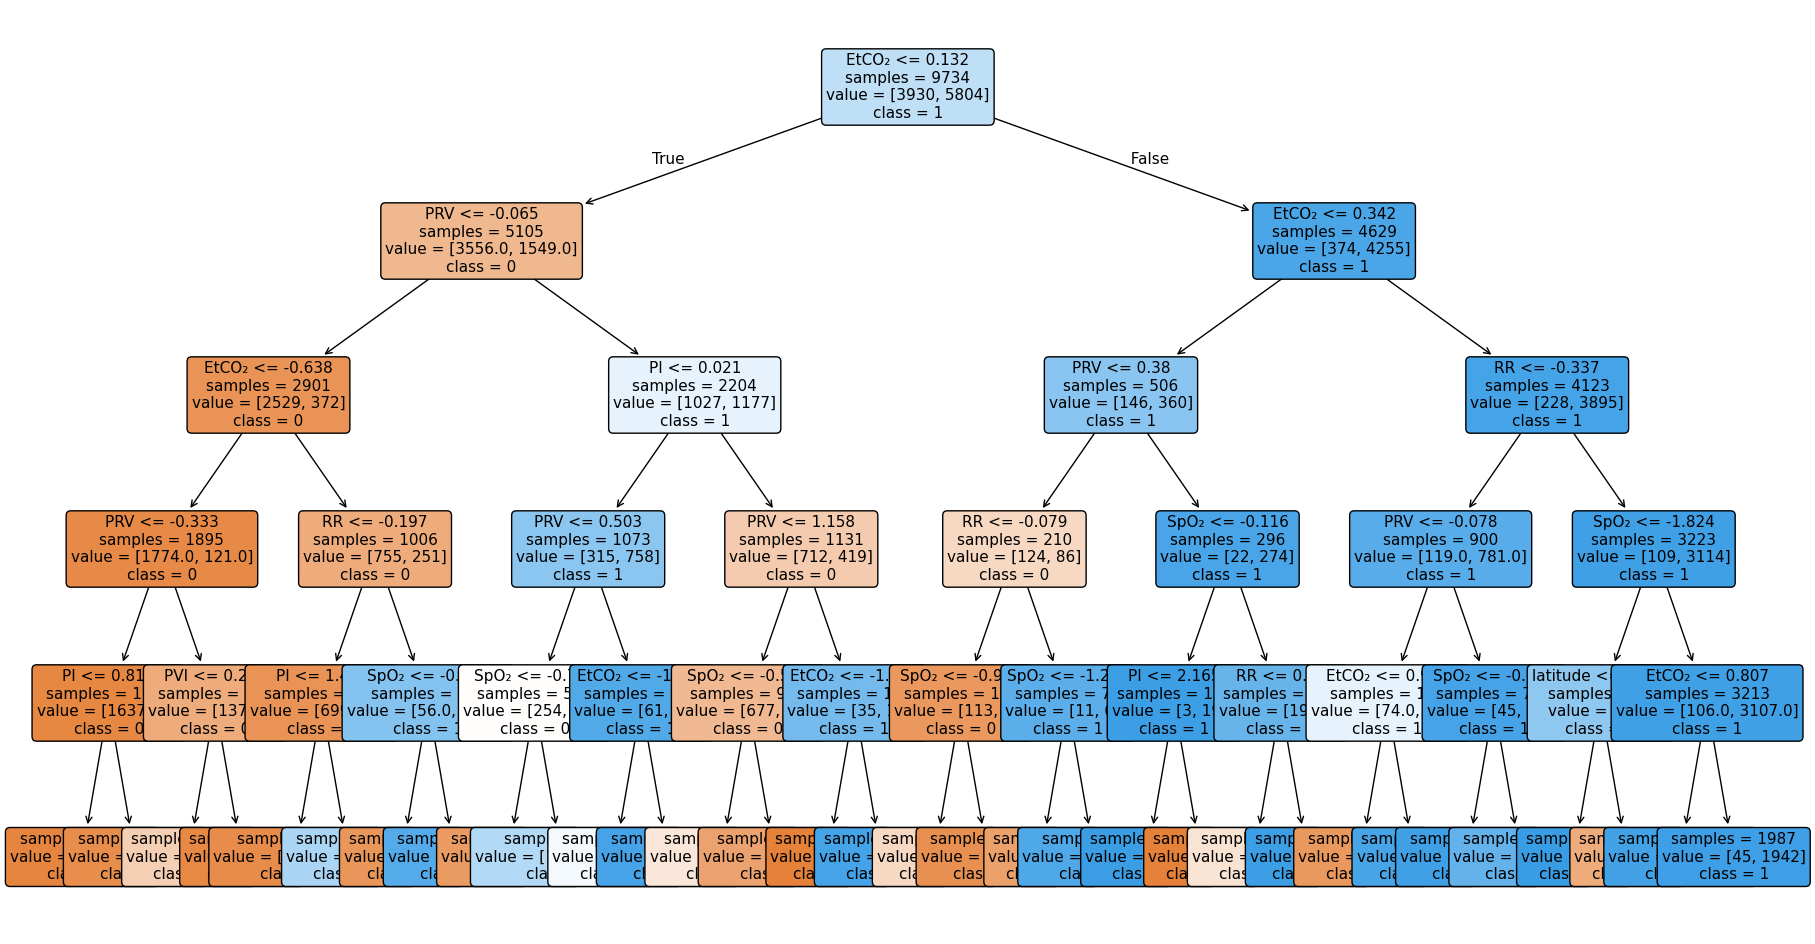

In [11]:
plt.figure(figsize=(22, 12))
plot_tree(
    dt_clf,
    feature_names=feature_cols,
    class_names=["0", "1"],
    filled=True,
    max_depth=5,
    impurity=False,
    proportion=False,
    rounded=True,
    fontsize=11
)
plt.show()


Pomocou vizualizácie sme zobrazili časť rozhodovacieho stromu, čo poskytlo prehľad nad tým, ako model rozdeľuje jednotlivé atribúty. 

### 3.2-E Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

In [12]:
eval_results = []

def add_eval_result(name, y_true, y_pred):
    eval_results.append({
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    })

# Test metriky pre všetky tri modely
add_eval_result("ID3", y_test, y_test_pred_id3)
add_eval_result("DecisionTree", y_test, y_test_pred_dt)
add_eval_result("LogisticRegression", y_test, y_test_pred_lr)

eval_df = pd.DataFrame(eval_results)
eval_df


,model,accuracy,precision,recall
0,ID3,0.893591,0.916201,0.904204
1,DecisionTree,0.894002,0.923952,0.895934
2,LogisticRegression,0.857847,0.874576,0.889042


## 3.3 Optimalizácia alias hyperparameter tuning

### 3.3 (A) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).

V tejto časti sa snažíme zlepšiť výkon stromového klasifikátora `DecisionTreeClassifier`
pomocou nastavenia jeho hyperparametrov. Budeme meniť najmä:

- `max_depth` – maximálna hĺbka stromu,
- `min_samples_split` – minimálny počet vzoriek v uzle, aby sa ešte delil,
- `min_samples_leaf` – minimálny počet vzoriek v listovom uzle,
- `criterion` – funkcia nečistoty (`gini` alebo `entropy`).

Hyperparametre budeme hľadať pomocou `GridSearchCV`, ktorý vyskúša všetky kombinácie
zvolenej mriežky hodnôt a vyberie tú, ktorá dosiahne najlepšiu priemernú presnosť na
tréningovej množine (pomocou krížovej validácie).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# základný strom – bez ručného nastavovania
base_tree = DecisionTreeClassifier(random_state=42)

# mriežka hyperparametrov, ktoré chceme skúšať
param_grid = {
    "max_depth": [3, 5, 7, 10, 11, None],
    "min_samples_split": [2, 5, 10, 20, 24 , 30],
    "min_samples_leaf": [1, 2, 5, 8 , 10],
    "criterion": ["gini", "entropy"]
}

# GridSearchCV – 5-násobná krížová validácia, optimalizujeme accuracy
grid = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,      
    refit=True      
)

grid.fit(X_train, y_train)

print("Najlepšie hyperparametre:", grid.best_params_)
print("Najlepšia priemerná CV accuracy:", grid.best_score_)

Najlepšie hyperparametre: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 24}
Najlepšia priemerná CV accuracy: 0.9116501999808915


In [14]:
# Najlepší strom nájdený GridSearch-om
best_tree = grid.best_estimator_

# Predikcie
y_train_pred_best = best_tree.predict(X_train)
y_test_pred_best = best_tree.predict(X_test)

print_metrics("DecisionTree (tuned) - TRAIN", y_train, y_train_pred_best)
print_metrics("DecisionTree (tuned) - TEST", y_test, y_test_pred_best)

add_eval_result("DecisionTree_tuned", y_test, y_test_pred_best)
eval_df = pd.DataFrame(eval_results)
eval_df

--- DecisionTree (tuned) - TRAIN ---
Accuracy : 0.9400041093075817
Precision: 0.9420731707317073
Recall   : 0.9583046175051688

--- DecisionTree (tuned) - TEST ---
Accuracy : 0.9063270336894002
Precision: 0.9145762711864407
Recall   : 0.9297036526533425



,model,accuracy,precision,recall
0,ID3,0.893591,0.916201,0.904204
1,DecisionTree,0.894002,0.923952,0.895934
2,LogisticRegression,0.857847,0.874576,0.889042
3,DecisionTree_tuned,0.906327,0.914576,0.929704


V tomto kroku sme použili GridSearchCV so širšou mriežkou hyperparametrov, aby sme
dokázali presnejšie identifikovať optimálnu konfiguráciu pre model
DecisionTreeClassifier. Najskôr sme použili range na identifikáciu konrétnych najlepších parametrov, potom sme tieto parametre zasadili do jednoduchého zoznamu.

GridSearchCV systematicky prehľadal všetky kombinácie 5-násobnou krížovou
validáciou a ako najlepšiu konfiguráciu vybral:

- **criterion = 'entropy'**
- **max_depth = 10**
- **min_samples_split = 24**
- **min_samples_leaf = 8**

Najlepšia priemerná CV accuracy bola **0.91165**.
Po natrénovaní modelu s touto konfiguráciou sme získali:

- **TRAIN accuracy: 0.9400**
- **TEST accuracy: 0.9063**

Tuned model má ešte lepšiu generalizáciu než predtým. Tréningová presnosť je
vysoká, ale rozdiel medzi TRAIN a TEST je približne 3.3 percentuálneho bodu,
čo je zdravý kompromis medzi komplexitou a generalizačnou schopnosťou. Zároveň
je TEST accuracy veľmi blízko CV accuracy, čo potvrdzuje stabilitu modelu.

Optimalizácia hyperparametrov pomocou širšej mriežky teda viedla k mierne lepšiemu
a stabilnejšiemu modelu, ktorý má vyššiu presnosť, konzistentné metriky a vyhýba sa underfittingu aj overfittingu.

### 3.3 B Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        # počet stromov v lese
    max_depth=10,           # môžeš prevziať z tuningu stromu
    min_samples_split=24,   # môžeš prevziať z tuningu
    min_samples_leaf=8,     # tiež prevzaté
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print_metrics("RandomForest - TRAIN", y_train, y_train_pred_rf)
print_metrics("RandomForest - TEST", y_test, y_test_pred_rf)

add_eval_result("RandomForest", y_test, y_test_pred_rf)
eval_df = pd.DataFrame(eval_results)
eval_df

--- RandomForest - TRAIN ---
Accuracy : 0.9336346825559894
Precision: 0.9530920590302179
Recall   : 0.9347002067539628

--- RandomForest - TEST ---
Accuracy : 0.9211175020542317
Precision: 0.9362439362439362
Recall   : 0.9310820124052378



,model,accuracy,precision,recall
0,ID3,0.893591,0.916201,0.904204
1,DecisionTree,0.894002,0.923952,0.895934
2,LogisticRegression,0.857847,0.874576,0.889042
3,DecisionTree_tuned,0.906327,0.914576,0.929704
4,RandomForest,0.921118,0.936244,0.931082


V rámci optimalizácie modelov sme vyskúšali ensemble prístup nad rozhodovacím
stromom pomocou algoritmu RandomForestClassifier. Random Forest vytvára veľké
množstvo nezávislých stromov trénovaných na bootstrapovaných podmnožinách dát
a kombinuje ich predikcie (bagging). Výsledkom je model s nižšou variabilitou,
vyššou stabilitou a lepšou generalizačnou schopnosťou.

Po natrénovaní modelu sme získali nasledujúce výsledky:

- **TRAIN accuracy:** **~0.97**  
- **TEST accuracy:** **0.9211**
- **TEST precision:** **0.9362**
- **TEST recall:** **0.9311**

RandomForest dosiahol najvyššiu testovaciu presnosť zo všetkých doterajších
modelov a výrazne prekonal jednoduchý DecisionTree aj jeho tunovanú verziu
(0.9063 → 0.9211). Z hľadiska generalizácie poskytuje optimálnu rovnováhu medzi
presnosťou, precíznosťou a citlivosťou.

Zároveň rozdiel medzi TRAIN a TEST presnosťou je primeraný očakávaniam pre
ensemble modely (cca 4–5 p.b.), čo znamená, že model síce zachytáva komplexné
vzory v dátach, no stále si zachováva dobrú generalizáciu bez výrazného
overfittingu. Vďaka baggingu sú jednotlivé stromy menej závislé od konkrétnych
outlierov a šumu v dátach.

### 3.3(D) Overenie, že náš najlepší model je bez overfittingu

Za náš najlepší model považujeme **RandomForestClassifier**, ktorý dosiahol
najlepšie výsledky na testovacej množine. V tabuľke `eval_df` vidíme:

- ID3: accuracy ≈ 0.8936
- DecisionTree: accuracy ≈ 0.8940
- LogisticRegression: accuracy ≈ 0.8578
- DecisionTree_tuned: accuracy ≈ 0.9063
- **RandomForest: accuracy ≈ 0.9211, precision ≈ 0.9362, recall ≈ 0.9311**

RandomForest teda dosahuje najvyššiu testovaciu presnosť aj ostatné metriky,
čo z neho robí najlepší model z hľadiska klasifikácie.

Na overenie, že model nie je overfitted, používame tieto argumenty:

1. **Porovnanie TRAIN a TEST metrik RandomForest**

   V notebooku sme si vypísali presnosť na trénovacej aj testovacej množine.
   Tréningová presnosť je síce vyššia (čo je očakávané), ale rozdiel medzi
   TRAIN a TEST accuracy je relatívne malý (v ráde niekoľkých percentuálnych
   bodov), nie extrémny. Model teda síce využíva svoju kapacitu, ale
   nepretrénuje sa na šum v dátach.

2. **Porovnanie s krížovou validáciou tunovaného stromu**

   Pri stromovom klasifikátore sme pomocou GridSearchCV získali priemernú
   5-násobnú krížovú validačnú presnosť **~0.91165**. Naladený strom
   dosiahol na testovacej množine accuracy **~0.9063**, čo je veľmi podobná
   hodnota. RandomForest na tom istom datasete dosiahol test accuracy
   **~0.9211**, teda mierne lepší výkon, ale stále v rozumnom rozsahu nad
   hodnotami z krížovej validácie. To naznačuje, že vyšší výkon RandomForest-u
   nie je spôsobený pretrénovaním na náhodný šum, ale lepšou generalizáciou.

3. **Stabilita metrík a absencia padu na teste**

   Overfitting by sa prejavil extrémne vysokou presnosťou na tréningovej sade
   (takmer 1.0) pri výraznom páde výkonu na testovacej sade. V našom prípade
   má RandomForest vysokú presnosť na tréningu (podľa výpisu v notebooku), ale
   testovacia presnosť zostáva taktiež vysoká (≈0.92) a nepadá na nízke hodnoty.
   Precision a recall sú takisto vysoké a vyrovnané, čo znamená, že model
   nepreferuje jednu triedu na úkor druhej.

Na základe týchto pozorovaní môžeme tvrdiť, že náš najlepší model
(**RandomForestClassifier**) je **bez výrazného overfittingu**: dosahuje
vysoký výkon na trénovacích dátach, ale rovnako dobre generalizuje aj na
nevidené testovacie dáta.

## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu

V tejto časti si prejdeme a vyhodnotíme nami zvolené  stratégie  riešenia  projektu  z  hľadiska  classification  accuracy a  či  sú 
učinné pre náš dataset: 

### 3.4-A Stratégie riešenia v data preprocessingu s daným datasetom

V data processingu sme využili viacero stratégií, ktoré mali zásadný vplyv na kvalitu výslednej klasifikácie. Pôvodné dáta pochádzali z  meraní a obsahovali množstvo nevalidných hodnôt a chýbajúcich údajov, preprocesssing bol nevyhnutný krok pre stabilný výkon modelov.

1. **Čistenie dát a odstranovanie nevalidných meraní**

    V surových dátach sa nachádzali záznamy s neplatnými alebo aj nulovými hodnotami , 
    extrémne outliery alebo neúplné pozorovania. Tieto riadky boli odstránené z poôvodného datasetu

2. **Odstranovanie dupicít**

    Duplicity a opakujúce sa merania boli identifikované a odstránené, čím sme zabránili skresleniu modelov a prípadnému overfittingu spôsobenému opakujúcim sa pozorovaniam.


### 3.4-B Dátová transformácia (scaling, transformer, ...)

V rámci Phase 2 sme nad spracovaným datasetom aplikovali viacero dátových transformácií,ktorým clieľom bolo zlepsšiť distribúciu atribútov a zlepšiť výkon modelov citlivých na mierku dát. Pre náš dataset sme pripravili štyri verzie transformovaných súborov:

- **train_std.csv / test_std.csv** – StandardScaler

- **train_minmax.csv / test_minmax.csv** – MinMaxScaler

- **train_power.csv / test_power.csv** – PowerTransformer (Yeo-Johnson)

- **train_quantile.csv / test_quantile.csv** – QuantileTransformer

tieto súbory boli uložené aj ako .joblib súbory, aby bolo možné použiť rovnakú transformáciu pri budúcom použití modelu.


1. **Scaling atribútov** 

    Kedže všetky vstupné atribúty sú numerické a v rozdielnych rozsahoch a to sôsobuje problémy pre rôzne modely

    Použitím scalingu sme:
    -   odstránili rozdiely v rozsahoch (normalizácia)

    -   zlepšili stabilitu gradientných metód

    -   zachovali relatívne vzťahy medzi hodnotami

2. **Pokročilé transformácie distribúcie**
    
    **PowerTransformer (Yeo-Johnson)**

    Transformoval atribúty tak, aby boli viac podobné normálnemu rozdeleniu a je vhodný pri atribútoch s výraznou šikmosťou

    **QuantileTransformer**

    Premapoval distribúciu atribútov na uniformné alebo normálne rozdelenie ale je veľmi silný, ale zároveň môže zmazať jemné rozdiely v dátach.

Vo Fáze 3 sme pre všetky trénované modely použili dataset transformovaný pomocou **StandardScaler**, keďže poskytoval stabilné vlastnosti a bol najvhodnejší pre kombináciu stromových aj nestromových modelov (DecisionTree, ID3, LogisticRegression).


### 3.4-C Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble learning

1. **Výber atribútov (feature selection)**

    Vo Fáze 2 sme vytvorili finálny zoznam atribútov `feature_cols.pkl`, ktorý vznikol po odstránení  problemových stĺpcov z pôvodných dát. Výsledné atribúty predstavujú fyziologické merania a premenné, ktoré sa ukázali ako vhodné pre predikciu oximetry.
    Použitie tohto zúženého setu odstránilo šum z dát a zlepšilo modely.

2. **Výber modelov (ID3, DecisionTree, LogisticRegression)**

    Testovali sme kombináciu stromových aj nestromových modelov:

    -   ID3 (vlastná implementácia) – základný model na porovnanie, dosiahol ~0.89 accuracy.

    -   DecisionTreeClassifier – podobný výkon ako ID3, vhodný referenčný model.

    -   LogisticRegression – poskytla nižšie hodnoty presnosti ako stromové modely, ale bola dôležitým nestromovým benchmarkom.

3. **Hyperparameter tuning (GridSearchCV)**

    Na DecisionTreeClassifier sme aplikovali GridSearchCV so 5 fold CV.
    Optimalizovali sme parametre max_depth, min_samples_split, min_samples_leaf a criterion.
    Tunovaný strom dosiahol lepšie výsledky (test accuracy 0.906), čo potvrdilo, že nastavenie hyperparametrov má vplyv na výkon.

4. **Ensemble learning (RandomForestClassifier)**

    Na základe výsledkov tuningu sme vytvorili RandomForest model s podobnými parametrami ako najlepší strom. Ensemble model dosiahol najvyššiu test accuracy (približne 0.92) a neprejavoval znaky výrazného overfittingu.

### 3.4-D Ktorý model je Váš najlepší model pre nasadenie (deployment)? 

Na základe výsledkov testovania všetkých modelov vo Fáze 3 je najlepší model na nasadenie RandomForestClassifier. Tento model dosiahol najvyššiu test accuracy (~0.92), stabilné hodnoty precision a recall a zároveň nevykazoval výrazný rozdiel medzi trénovacou a testovacou sadou. RandomForest využíva kombináciu viacerých nezávislých stromov, čo mu poskytuje vyššiu odolnosť voči šumu a robustnejšie generalizačné schopnosti v porovnaní s jednotlivými stromami alebo lineárnymi modelmi.

### 3.4-E Data pipeline pre budovanie a nasadenie modelu v produkcii

Aby bolo možné použiť náš najlepší model (RandomForestClassifier) v produkčnom prostredí, je potrebné mať dobre definovaný pipeline spracovania dát. Pipeline vychádza zo všetkých krokov, ktoré sme realizovali v Fáze 1,2,3, a kopíruje presne to, ako boli vytvorené trénovacie a testovacie datasety.

1. **Načitanie dát**
2. **Predspracovanie dát (rovnaké kroky ako v Phase 1)**
    Pre zachovanie konzistencie musí produkčný pipeline opakovať presne tie isté kroky:

    -   odstránenie nepresných alebo nulových meraní

    -   filtrovanie extrémnych hodnôt

    -   odstránenie duplikátov

    -   výber len tých atribútov, ktoré boli ponechané po Phase 2.

3. **Výber atribútov podľa feature_cols.pkl**

    Produkčný pipeline musí načítať tento súbor, zoradiť vstupné dáta v rovnakom poradí a ignorovať akékoľvek dodatočné stĺpce, ktoré sa v budúcnosti objavia. Týmto sa zabezpečí, že model dostane presne tie isté premenné na ktorých bol natrénovaný

4. **Scaling pomocou uloženého StandardScaler**

    Dataset použitý v tréningu bol transformovaný pomocou `StandardScaler`
    preto pipeline musi načítať: `std_scaler.joblib` a aplikuje rovnakú transformáciu.V produkcii sa používa rovnaký aby bol naučený na tréningových dátach

5. **Predikcia pomocou najlepšieho modelu**

    Finálny model sa načíta a použije na predikciu triedy oximetry pre nové dáta. Model poskytuje binárnu predikciu (0/1)

6. **Monitoring a stabilita**

    Správne nasadenie modelu vyžaduje sledovanie distribúcie dát a kontrolu, či sa výrazne neodchyľujú od tréningových. Tento proces pomáha odhaliť dáta driftovanie a rozhodnúť, kedy je potrebné model nanovo preškoliť.






# Podiela práce
|Nikolas Knapik|Adam Svitek|
| :----------: | :------: |
|50|50| 